# Analisi Statistica dei Campi di Influenza

Obiettivo: capire se i campi C(x) contengono informazione scacchistica reale
**prima** di addestrare qualsiasi rete neurale.

Domande:
1. ΣC(x) correla con la valutazione Stockfish?
2. La mossa migliore massimizza ‖ΔC‖ rispetto alle altre mosse legali?
3. I campi distinguono posizioni tattiche da posizionali?
4. Quali feature del campo sono più informative?

In [5]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as mpe
from matplotlib.patches import Rectangle
from scipy import stats
import chess
import warnings
warnings.filterwarnings('ignore')

from chess_fields import compute_fields_from_fen

# -----------------------------------------------------------------------
# MODIFICA QUESTO PATH
# -----------------------------------------------------------------------
CSV_PATH = '../over_mate_1_tactic_evals.csv'

# Quante righe analizzare (None = tutto il dataset)
# Inizia con 10_000 per velocità, poi togli il limite
N_SAMPLE = 10_000

ALPHA = 0.5
print('Setup completato.')

Setup completato.


## 1. Caricamento e pulizia del CSV

In [6]:
df = pd.read_csv(CSV_PATH)
if N_SAMPLE:
    df = df.sample(n=min(N_SAMPLE, len(df)), random_state=42).reset_index(drop=True)

print(f'Posizioni caricate: {len(df):,}')
print(df.head(3))

def parse_eval(e):
    e = str(e).strip()
    if '#' in e:
        # #+2 → +1000, #-2 → -1000
        return 1000.0 if '+' in e else -1000.0
    try:
        return float(e)
    except:
        return np.nan

df['eval_num'] = df['Evaluation'].apply(parse_eval)

# Tipo di posizione
df['is_mate']     = df['Evaluation'].astype(str).str.contains('#')
df['eval_clipped'] = df['eval_num'].clip(-1000, 1000)  # per grafici
df['eval_abs']     = df['eval_num'].abs()

print(f"\nMatti: {df['is_mate'].sum():,}  ({df['is_mate'].mean()*100:.1f}%)")
print(f"Posizioni bilanciate (|eval|<100): {(df['eval_abs']<100).sum():,}")
print(f"Posizioni sbilanciate (|eval|>500): {(df['eval_abs']>500).sum():,}")

Posizioni caricate: 10,000
                                                 FEN Evaluation  Move
0   r6k/p1p4p/2p1Qpb1/2q5/8/2P5/P5PP/4R2K w - - 0 26       +236  e6f6
1  r2r2k1/pppq4/2n2Q2/1n2p3/7R/3P2P1/PP3PK1/R1N5 ...       +410  d7g7
2  r5k1/p1p2ppp/2bp2r1/8/4P1q1/1PNBP3/P1P2RPP/R3n...       -640  a1e1

Matti: 276  (2.8%)
Posizioni bilanciate (|eval|<100): 320
Posizioni sbilanciate (|eval|>500): 4,284


## 2. Calcolo delle feature dei campi
Questo è il passo lento — ~2 min per 10k posizioni.

In [7]:
import time

def extract_field_features(fen, alpha=ALPHA):
    """
    Estrae feature scalari dal campo di influenza.
    Ritorna un dict con tutte le feature.
    """
    try:
        fields = compute_fields_from_fen(fen, alpha=alpha)
        W = fields['white']
        B = fields['black']
        C = fields['control']

        # Tensione: case dove entrambi i lati hanno influenza alta
        tension = np.minimum(W, B)

        return {
            'C_sum':        C.sum(),           # controllo netto totale
            'C_abs_sum':    np.abs(C).sum(),   # intensità totale
            'C_max':        C.max(),            # picco bianco
            'C_min':        C.min(),            # picco nero
            'C_std':        C.std(),            # varianza del campo
            'W_sum':        W.sum(),            # influenza totale bianco
            'B_sum':        B.sum(),            # influenza totale nero
            'tension_sum':  tension.sum(),      # tensione totale
            'tension_max':  tension.max(),      # picco di tensione
            'n_white_ctrl': (C > 0.1).sum(),   # case dominate dal bianco
            'n_black_ctrl': (C < -0.1).sum(),  # case dominate dal nero
            'n_contested':  (np.abs(C) <= 0.1).sum(),  # case contestate
        }
    except:
        return {k: np.nan for k in [
            'C_sum','C_abs_sum','C_max','C_min','C_std',
            'W_sum','B_sum','tension_sum','tension_max',
            'n_white_ctrl','n_black_ctrl','n_contested'
        ]}

print('Calcolo campi in corso...')
t0 = time.time()

features = [extract_field_features(fen) for fen in df['FEN']]
feat_df  = pd.DataFrame(features)
df       = pd.concat([df, feat_df], axis=1)

elapsed = time.time() - t0
print(f'Fatto in {elapsed:.1f}s  ({len(df)/elapsed:.0f} pos/s)')
print(f'Feature estratte: {feat_df.columns.tolist()}')

Calcolo campi in corso...
Fatto in 14.7s  (681 pos/s)
Feature estratte: ['C_sum', 'C_abs_sum', 'C_max', 'C_min', 'C_std', 'W_sum', 'B_sum', 'tension_sum', 'tension_max', 'n_white_ctrl', 'n_black_ctrl', 'n_contested']


## 3. Correlazione con la valutazione Stockfish

Posizioni non-matto: 9,724

Correlazione di Pearson con eval_num:
---------------------------------------------
  C_sum                r=-0.016  p=1.26e-01 
  C_abs_sum            r=+0.014  p=1.81e-01 
  C_max                r=-0.015  p=1.42e-01 
  C_min                r=-0.029  p=3.64e-03 **
  C_std                r=+0.011  p=3.00e-01 
  W_sum                r=-0.005  p=6.49e-01 
  B_sum                r=+0.004  p=7.18e-01 
  tension_sum          r=-0.004  p=7.00e-01 
  tension_max          r=+0.007  p=5.14e-01 
  n_white_ctrl         r=-0.017  p=9.39e-02 
  n_black_ctrl         r=+0.021  p=3.76e-02 *
  n_contested          r=-0.007  p=4.91e-01 


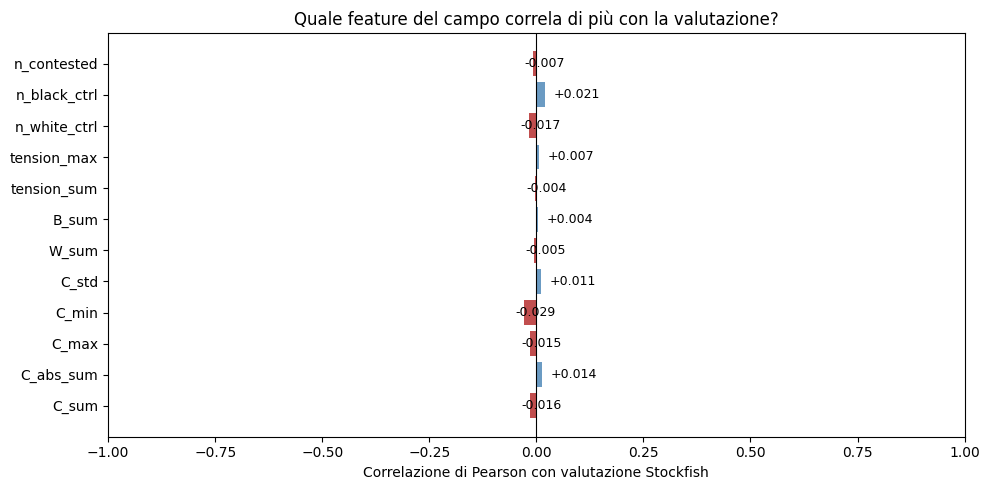

In [8]:
field_features = ['C_sum','C_abs_sum','C_max','C_min','C_std',
                  'W_sum','B_sum','tension_sum','tension_max',
                  'n_white_ctrl','n_black_ctrl','n_contested']

# Solo posizioni non-matto per la correlazione lineare
df_no_mate = df[~df['is_mate']].dropna(subset=field_features + ['eval_num'])

print(f'Posizioni non-matto: {len(df_no_mate):,}')
print('\nCorrelazione di Pearson con eval_num:')
print('-' * 45)

correlations = {}
for feat in field_features:
    r, p = stats.pearsonr(df_no_mate[feat], df_no_mate['eval_num'])
    correlations[feat] = (r, p)
    stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f'  {feat:<20} r={r:+.3f}  p={p:.2e} {stars}')

# Visualizza
feat_names = list(correlations.keys())
r_values   = [correlations[f][0] for f in feat_names]

fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['steelblue' if r > 0 else 'firebrick' for r in r_values]
bars    = ax.barh(feat_names, r_values, color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlazione di Pearson con valutazione Stockfish')
ax.set_title('Quale feature del campo correla di più con la valutazione?')
ax.set_xlim(-1, 1)
for bar, r in zip(bars, r_values):
    ax.text(r + 0.02 * np.sign(r), bar.get_y() + bar.get_height()/2,
            f'{r:+.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 4. La mossa migliore massimizza ‖ΔC‖?
Confrontiamo il delta del campo della mossa Stockfish
vs la media delle altre mosse legali.

**Questo è il test più importante.**

In [9]:
def compute_move_deltas(fen, best_move_uci, alpha=ALPHA, max_legal=None):
    """
    Per una posizione, calcola:
    - delta_best:  ‖ΔC‖ della mossa migliore
    - delta_mean:  media di ‖ΔC‖ su tutte le mosse legali
    - delta_max:   massimo ‖ΔC‖ tra tutte le mosse legali
    - rank:        posizione della mossa migliore nel ranking per ‖ΔC‖
    - n_legal:     numero di mosse legali
    """
    try:
        board   = chess.Board(fen)
        C_before = compute_fields_from_fen(fen, alpha=alpha)['control']

        legal_moves = list(board.legal_moves)
        if max_legal:
            legal_moves = legal_moves[:max_legal]

        deltas = {}
        for move in legal_moves:
            board.push(move)
            C_after = compute_fields_from_fen(board.fen(), alpha=alpha)['control']
            board.pop()
            deltas[move.uci()] = np.linalg.norm(C_after - C_before)

        if not deltas:
            return None

        sorted_moves = sorted(deltas.items(), key=lambda x: -x[1])
        delta_values = list(deltas.values())

        delta_best = deltas.get(best_move_uci, np.nan)
        rank = next((i+1 for i, (m,_) in enumerate(sorted_moves)
                     if m == best_move_uci), np.nan)

        return {
            'delta_best': delta_best,
            'delta_mean': np.mean(delta_values),
            'delta_max':  np.max(delta_values),
            'delta_std':  np.std(delta_values),
            'rank':       rank,
            'n_legal':    len(deltas),
            'percentile': 100 * (1 - (rank-1) / len(deltas)) if rank else np.nan,
        }
    except:
        return None

# Campiona un sottoinsieme (ogni posizione richiede N_legal BFS)
N_DELTA = min(500, len(df))
df_delta = df.sample(n=N_DELTA, random_state=42).reset_index(drop=True)

print(f'Calcolo delta su {N_DELTA} posizioni (può richiedere 2-5 min)...')
t0 = time.time()

delta_results = []
for i, row in df_delta.iterrows():
    result = compute_move_deltas(row['FEN'], row['Move'], max_legal=20)
    if result:
        delta_results.append(result)

delta_df = pd.DataFrame(delta_results).dropna()
print(f'Fatto in {time.time()-t0:.1f}s  |  Posizioni valide: {len(delta_df)}')

Calcolo delta su 500 posizioni (può richiedere 2-5 min)...
Fatto in 13.0s  |  Posizioni valide: 403


=== Risultati: la mossa migliore massimizza ‖ΔC‖? ===

Delta medio mossa migliore:  1.8969
Delta medio mosse qualsiasi: 1.3685
Rapporto best/mean:          1.376

Rank medio della mossa migliore: 4.48 (su 14.8 mosse legali medie)
Percentile medio:                77.4%

% volte in cui best_move è rank #1:  43.7%
% volte in cui best_move è top-3:    62.0%
% volte in cui best_move è top-5:    72.7%

T-test (best > mean): t=14.345, p=0.0000
→ SIGNIFICATIVO: la mossa migliore ha ‖ΔC‖ sistematicamente diverso dalla media.


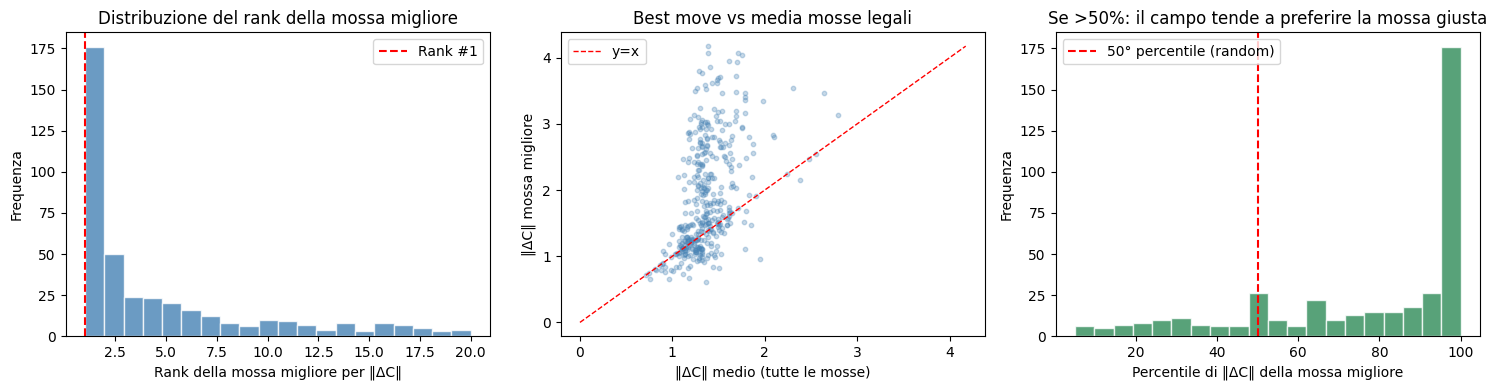

In [10]:
print('=== Risultati: la mossa migliore massimizza ‖ΔC‖? ===')
print()
print(f'Delta medio mossa migliore:  {delta_df["delta_best"].mean():.4f}')
print(f'Delta medio mosse qualsiasi: {delta_df["delta_mean"].mean():.4f}')
print(f'Rapporto best/mean:          {(delta_df["delta_best"]/delta_df["delta_mean"]).mean():.3f}')
print()
print(f'Rank medio della mossa migliore: {delta_df["rank"].mean():.2f} '
      f'(su {delta_df["n_legal"].mean():.1f} mosse legali medie)')
print(f'Percentile medio:                {delta_df["percentile"].mean():.1f}%')
print()
print(f'% volte in cui best_move è rank #1:  {(delta_df["rank"]==1).mean()*100:.1f}%')
print(f'% volte in cui best_move è top-3:    {(delta_df["rank"]<=3).mean()*100:.1f}%')
print(f'% volte in cui best_move è top-5:    {(delta_df["rank"]<=5).mean()*100:.1f}%')
print()

# Test statistico: delta_best > delta_mean?
t_stat, p_val = stats.ttest_rel(
    delta_df['delta_best'].dropna(),
    delta_df['delta_mean'].dropna()
)
print(f'T-test (best > mean): t={t_stat:.3f}, p={p_val:.4f}')
if p_val < 0.05:
    print('→ SIGNIFICATIVO: la mossa migliore ha ‖ΔC‖ sistematicamente diverso dalla media.')
else:
    print('→ Non significativo: ‖ΔC‖ non distingue la mossa migliore.')

# Visualizza distribuzione dei rank
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(delta_df['rank'], bins=20, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(1, color='red', linestyle='--', label='Rank #1')
axes[0].set_xlabel('Rank della mossa migliore per ‖ΔC‖')
axes[0].set_ylabel('Frequenza')
axes[0].set_title('Distribuzione del rank della mossa migliore')
axes[0].legend()

axes[1].scatter(delta_df['delta_mean'], delta_df['delta_best'],
                alpha=0.3, s=10, color='steelblue')
lim = max(delta_df['delta_best'].max(), delta_df['delta_mean'].max())
axes[1].plot([0, lim], [0, lim], 'r--', linewidth=1, label='y=x')
axes[1].set_xlabel('‖ΔC‖ medio (tutte le mosse)')
axes[1].set_ylabel('‖ΔC‖ mossa migliore')
axes[1].set_title('Best move vs media mosse legali')
axes[1].legend()

axes[2].hist(delta_df['percentile'], bins=20, color='seagreen', alpha=0.8, edgecolor='white')
axes[2].axvline(50, color='red', linestyle='--', label='50° percentile (random)')
axes[2].set_xlabel('Percentile di ‖ΔC‖ della mossa migliore')
axes[2].set_ylabel('Frequenza')
axes[2].set_title('Se >50%: il campo tende a preferire la mossa giusta')
axes[2].legend()

plt.tight_layout()
plt.show()

## 5. Posizioni tattiche vs posizionali

Distribuzione categorie:
category
sbilanciata    7466
bilanciata     2258
matto           276
Name: count, dtype: int64



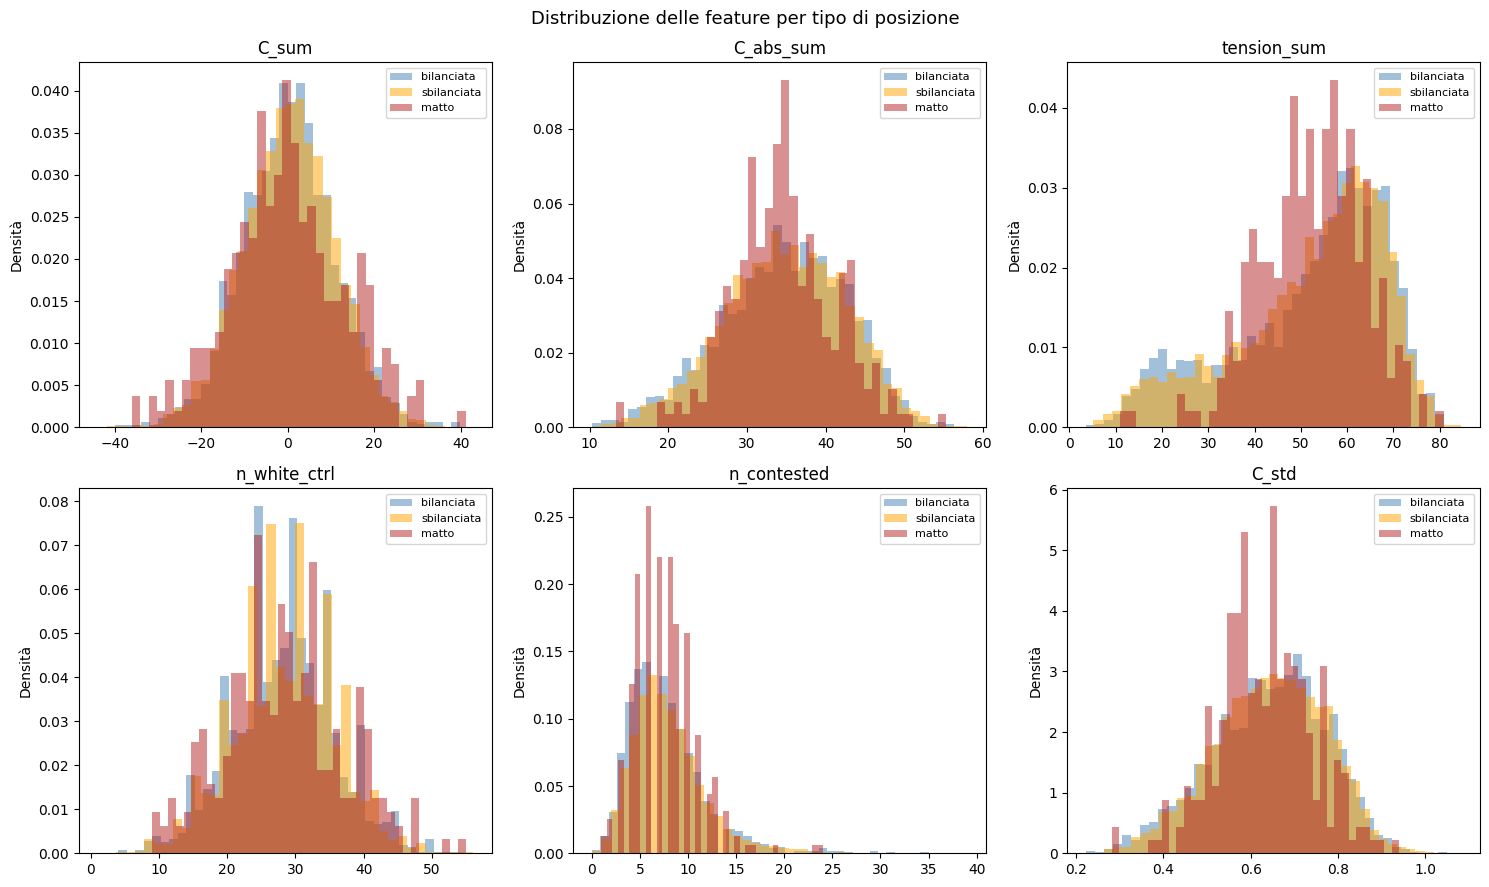


Media delle feature per categoria:
             C_sum  C_abs_sum  tension_sum  n_white_ctrl  n_contested  C_std
category                                                                    
bilanciata   0.383     34.748       51.969        28.219        7.743  0.642
matto       -0.001     34.546       52.403        28.257        7.667  0.631
sbilanciata  0.507     34.873       52.000        28.364        7.696  0.645


In [11]:
# Categorie
df['category'] = 'bilanciata'
df.loc[df['eval_abs'] > 300, 'category'] = 'sbilanciata'
df.loc[df['is_mate'], 'category'] = 'matto'

print('Distribuzione categorie:')
print(df['category'].value_counts())
print()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
features_to_plot = ['C_sum', 'C_abs_sum', 'tension_sum',
                    'n_white_ctrl', 'n_contested', 'C_std']
categories  = ['bilanciata', 'sbilanciata', 'matto']
cat_colors  = {'bilanciata': 'steelblue', 'sbilanciata': 'orange', 'matto': 'firebrick'}

for ax, feat in zip(axes.flat, features_to_plot):
    for cat in categories:
        data = df[df['category'] == cat][feat].dropna()
        if len(data) > 0:
            ax.hist(data, bins=40, alpha=0.5,
                    color=cat_colors[cat], label=cat,
                    density=True, edgecolor='none')
    ax.set_title(feat)
    ax.set_ylabel('Densità')
    ax.legend(fontsize=8)

plt.suptitle('Distribuzione delle feature per tipo di posizione', fontsize=13)
plt.tight_layout()
plt.show()

# Statistiche per categoria
print('\nMedia delle feature per categoria:')
print(df.groupby('category')[features_to_plot].mean().round(3).to_string())

## 6. Mutual Information con la valutazione
La correlazione di Pearson cattura solo relazioni lineari.
La mutual information cattura anche relazioni non lineari.

Feature ranked per Mutual Information:
     feature  mutual_info  pearson_r
 tension_max     0.039952   0.006614
   C_abs_sum     0.023941   0.013563
       W_sum     0.021131   0.004618
 tension_sum     0.019015   0.003907
 n_contested     0.017745   0.006991
       B_sum     0.017090   0.003660
       C_sum     0.014319   0.015532
       C_std     0.012263   0.010517
n_black_ctrl     0.010610   0.021087
n_white_ctrl     0.008236   0.016986
       C_max     0.007808   0.014890
       C_min     0.000328   0.029484


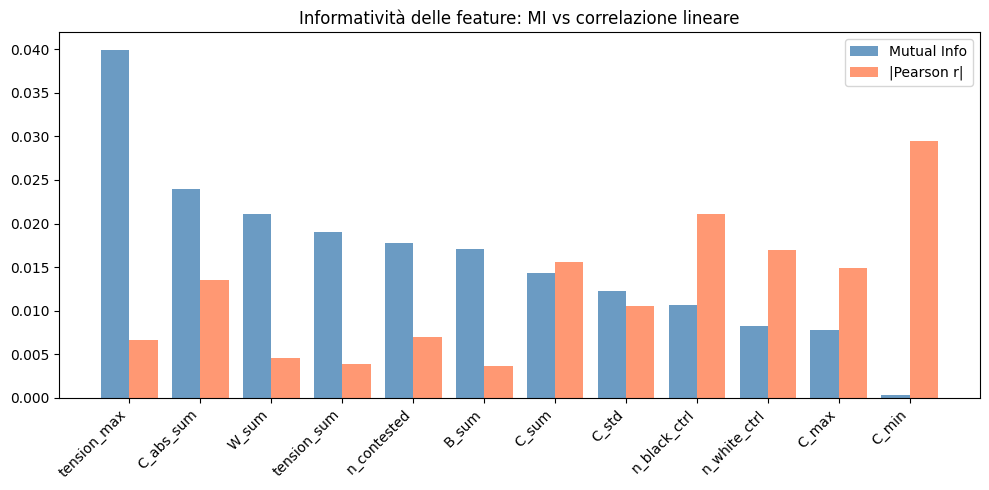

In [12]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import QuantileTransformer

df_clean = df[~df['is_mate']].dropna(subset=field_features + ['eval_num'])

X = df_clean[field_features].values
y = df_clean['eval_num'].values

# Normalizza per MI
qt = QuantileTransformer(output_distribution='normal')
X_norm = qt.fit_transform(X)

mi_scores = mutual_info_regression(X_norm, y, random_state=42)

mi_df = pd.DataFrame({
    'feature': field_features,
    'mutual_info': mi_scores,
    'pearson_r': [abs(correlations[f][0]) for f in field_features]
}).sort_values('mutual_info', ascending=False)

print('Feature ranked per Mutual Information:')
print(mi_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(field_features))
width = 0.4

mi_sorted  = mi_df['mutual_info'].values
pear_sorted = mi_df['pearson_r'].values
names_sorted = mi_df['feature'].values

ax.bar(x_pos - width/2, mi_sorted,  width, label='Mutual Info', color='steelblue', alpha=0.8)
ax.bar(x_pos + width/2, pear_sorted, width, label='|Pearson r|', color='coral',    alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(names_sorted, rotation=45, ha='right')
ax.set_title('Informatività delle feature: MI vs correlazione lineare')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Quanto α influenza i risultati?
Testiamo α ∈ {0.3, 0.5, 0.7, 0.9} su un campione piccolo.

α=0.3:  r=-0.0545  p=8.47e-02
α=0.5:  r=-0.0456  p=1.49e-01
α=0.7:  r=-0.0553  p=8.08e-02
α=0.9:  r=-0.0642  p=4.24e-02


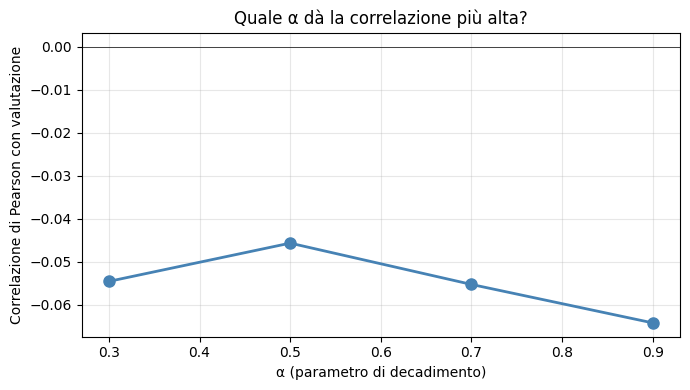


Miglior α per correlazione lineare: 0.9


In [13]:
N_ALPHA = min(1000, len(df))
df_alpha = df[~df['is_mate']].sample(n=N_ALPHA, random_state=0).reset_index(drop=True)

alphas = [0.3, 0.5, 0.7, 0.9]
alpha_results = {}

for a in alphas:
    c_sums = []
    for fen in df_alpha['FEN']:
        try:
            c_sums.append(compute_fields_from_fen(fen, alpha=a)['control'].sum())
        except:
            c_sums.append(np.nan)
    valid = [(c, e) for c, e in zip(c_sums, df_alpha['eval_num']) if not np.isnan(c)]
    cs, es = zip(*valid)
    r, p = stats.pearsonr(cs, es)
    alpha_results[a] = {'r': r, 'p': p}
    print(f'α={a}:  r={r:+.4f}  p={p:.2e}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, [alpha_results[a]['r'] for a in alphas],
        'o-', color='steelblue', linewidth=2, markersize=8)
ax.set_xlabel('α (parametro di decadimento)')
ax.set_ylabel('Correlazione di Pearson con valutazione')
ax.set_title('Quale α dà la correlazione più alta?')
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_alpha = max(alphas, key=lambda a: abs(alpha_results[a]['r']))
print(f'\nMiglior α per correlazione lineare: {best_alpha}')

## 8. Riepilogo e decisione

In [14]:
print('=' * 55)
print('RIEPILOGO')
print('=' * 55)

best_feat = max(correlations, key=lambda f: abs(correlations[f][0]))
best_r    = correlations[best_feat][0]
print(f'\n1. CORRELAZIONE CON VALUTAZIONE')
print(f'   Feature più correlata: {best_feat} (r={best_r:+.3f})')
if abs(best_r) > 0.5:
    print('   → BUONO: correlazione forte, i campi hanno senso.')
elif abs(best_r) > 0.3:
    print('   → DISCRETO: correlazione moderata, utile come feature aggiuntiva.')
else:
    print('   → DEBOLE: i campi da soli non catturano la valutazione.')

if len(delta_df) > 0:
    pct_top1  = (delta_df['rank'] == 1).mean() * 100
    pct_top3  = (delta_df['rank'] <= 3).mean() * 100
    mean_pct  = delta_df['percentile'].mean()
    print(f'\n2. PREDIZIONE DELLA MOSSA')
    print(f'   Best move è rank #1 per ‖ΔC‖: {pct_top1:.1f}% delle posizioni')
    print(f'   Best move è top-3:             {pct_top3:.1f}%')
    print(f'   Percentile medio:              {mean_pct:.1f}%  (random = 50%)')
    if mean_pct > 65:
        print('   → OTTIMO: il campo tende a preferire le mosse buone.')
    elif mean_pct > 55:
        print('   → DISCRETO: segnale debole ma reale.')
    else:
        print('   → NULLO: ‖ΔC‖ non predice la mossa migliore.')

print(f'\n3. DISTINZIONE TATTICA/POSIZIONALE')
for feat in ['tension_sum', 'C_std', 'n_contested']:
    means = df.groupby('category')[feat].mean()
    print(f'   {feat}:')
    for cat, val in means.items():
        print(f'     {cat:<15} {val:.3f}')

print(f'\n4. MIGLIOR α: {best_alpha}')
print()
print('CONCLUSIONE:')
print('  Se correlazione > 0.4 E percentile > 55%:')
print('  → Vale la pena addestrare ResNet con i campi come feature.')
print('  → Usa α =', best_alpha, 'per il precomputing.')

RIEPILOGO

1. CORRELAZIONE CON VALUTAZIONE
   Feature più correlata: C_min (r=-0.029)
   → DEBOLE: i campi da soli non catturano la valutazione.

2. PREDIZIONE DELLA MOSSA
   Best move è rank #1 per ‖ΔC‖: 43.7% delle posizioni
   Best move è top-3:             62.0%
   Percentile medio:              77.4%  (random = 50%)
   → OTTIMO: il campo tende a preferire le mosse buone.

3. DISTINZIONE TATTICA/POSIZIONALE
   tension_sum:
     bilanciata      51.969
     matto           52.403
     sbilanciata     52.000
   C_std:
     bilanciata      0.642
     matto           0.631
     sbilanciata     0.645
   n_contested:
     bilanciata      7.743
     matto           7.667
     sbilanciata     7.696

4. MIGLIOR α: 0.9

CONCLUSIONE:
  Se correlazione > 0.4 E percentile > 55%:
  → Vale la pena addestrare ResNet con i campi come feature.
  → Usa α = 0.9 per il precomputing.
